In [1]:
import utils
import model
import layers
from torch import optim
from torch.utils import data
from torchvision import datasets, transforms
from IPython import display
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
m = model.UNet(3, 64, 128, 256, MoEBlock_type=layers.DynamicMoEBlock, k=1).to(device)
m = model.DDPM(m)
opt = optim.Adam(m.parameters(), 2e-4)

batch_size = 100

tf = transforms.Compose([
    transforms.ToTensor(),
])
train_set = datasets.CIFAR10('data', train=True, download=True, transform=tf)
train_dl = data.DataLoader(train_set, batch_size, shuffle=True)


100%|██████████| 100/100 [00:08<00:00, 11.35it/s]

Demo saved to /content/demo_0.png



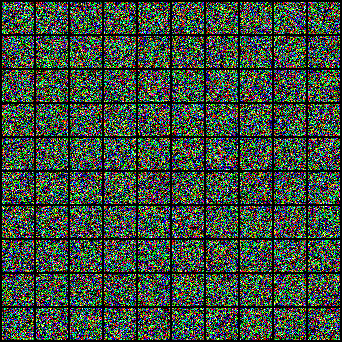

100%|██████████| 100/100 [00:07<00:00, 12.86it/s]


Demo saved to /content/demo_1.png



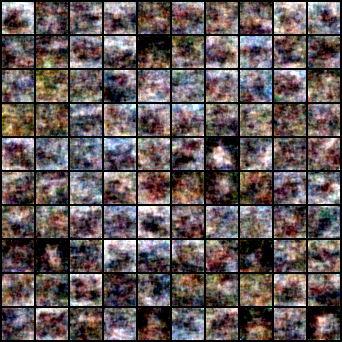

100%|██████████| 100/100 [00:07<00:00, 12.87it/s]


Demo saved to /content/demo_2.png



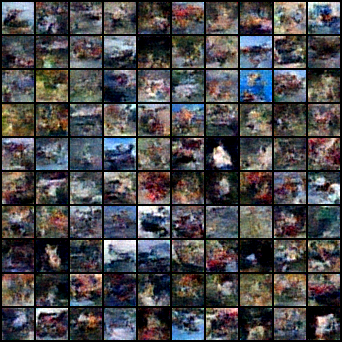

100%|██████████| 100/100 [00:07<00:00, 12.91it/s]


Demo saved to /content/demo_3.png



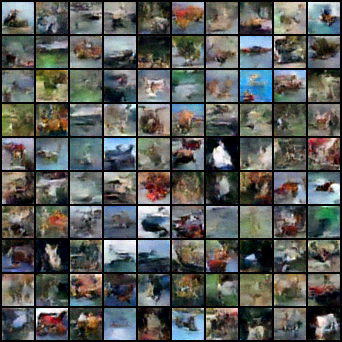

100%|██████████| 100/100 [00:07<00:00, 12.91it/s]


Demo saved to /content/demo_4.png



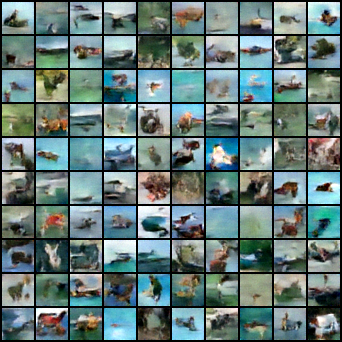

100%|██████████| 100/100 [00:07<00:00, 12.87it/s]


Demo saved to /content/demo_5.png



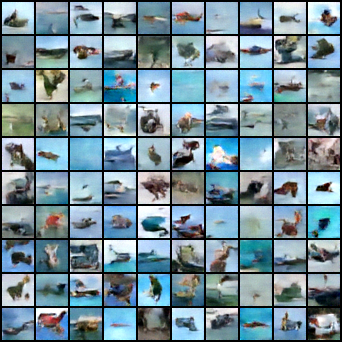

In [3]:
grid = utils.demo(m, (32, 32), 100, 10, filename='demo_0.png')
display.display(display.Image('demo_0.png'))
print()
for i in range(5):
    utils.train(m, train_dl, opt)
    grid = utils.demo(m, (32, 32), 100, 10, filename=f'demo_{i+1}.png')
    display.display(display.Image(f'demo_{i+1}.png'))
    print()